# Notebook 09 - Experimento 5: Predicción a distintos horizontes temporales

## Pregunta de investigación
¿Cómo degrada el rendimiento de cada modelo al aumentar el horizonte de predicción?
¿Qué modelos son más robustos ante horizontes largos?

## Diseño experimental
Las *features* de entrada son exactamente las mismas en los tres horizontes
evaluados (*lags*, *rolling*, radiación, temperatura, variables temporales).
Lo que cambia es unicamente el target: en lugar de predecir `power_pu[t]`,
se predice `power_pu[t+h]`.

| Horizonte | Steps | Tiempo real |
|---|---|---|
| t+1  | 1  | 15 minutos |
| t+4  | 4  | 1 hora |
| t+16 | 16 | 4 horas |

## Puntos metodológicos clave
- Los *lags* son información del **pasado** (features); el horizonte define
  qué **futuro** se predice (*target*).
- Este experimento es complementario al de *lags*: mientras aquel estudia
  qué información del pasado aporta más, este cuantifica la dificultad
  de predecir el futuro.
- `features_horas.py` extiende `features.py` con soporte para *targets*
  desplazados múltiples horizontes.


### 1. Configuración de rutas e importaciones


In [1]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px

current = Path().resolve()
root = current.anchor
while not ((current / "data").exists() and (current / "src").exists()):
    if str(current) == root:
        raise FileNotFoundError(
            "No se encontro la raíz del proyecto. "
            "Asegurate de que existen las carpetas data/ y src/."
        )
    current = current.parent

os.chdir(current)
if str(current) not in sys.path:
    sys.path.insert(0, str(current))

PROJECT_ROOT = current
DATA_DIR    = PROJECT_ROOT / "data"
RESULTS_DIR = DATA_DIR / "results"

from src.data import add_nominal_power_and_target, basic_cleaning, split_train_val_test
from src.evaluation import compute_metrics
from src.features_horas import (
    FeatureConfig,
    build_features,
    get_feature_columns,
    add_forecast_horizon_targets,
    get_horizon_target_columns,
)
from src.models import get_baseline_models

warnings.filterwarnings("ignore", category=FutureWarning)
print(f"Raíz del proyecto: {PROJECT_ROOT.name}")


Raíz del proyecto: TFM_RPUEBAS


### 2. Carga y preparación de datos


In [2]:
HORIZONS = {
    1:  "t+1 (15 min)",
    4:  "t+4 (1 hora)",
    16: "t+16 (4 horas)",
}

df_all = pd.read_csv(DATA_DIR / "df_all_unificado.csv", parse_dates=["timestamp"])
df_all = basic_cleaning(df_all)
df_all = df_all.drop(columns=["power_pu", "p_nominal_kw"], errors="ignore")
df_all = add_nominal_power_and_target(df_all, {"E03": 12.4, "Afrisol": 12.0, "LECA1": 19.53})

print("Datos disponibles por planta:")
display(df_all.groupby("id_planta")["timestamp"].agg(["min", "max", "count"]))


Datos disponibles por planta:


,min,max,count
id_planta,,,
Afrisol,2022-01-01,2024-04-29 23:45:00,81111
E03,2022-01-01,2024-05-30 23:45:00,84087
LECA1,2022-01-01,2024-05-30 23:45:00,84087


### 3. Ingeniería de variables con lag


In [3]:
config = FeatureConfig(
    lag_steps_power=(1, 2, 4),
    lag_steps_radiation=(1, 2),
    rolling_windows_power=(4, 8),
    rolling_windows_radiation=(4,),
    add_interactions=True,
    add_daylight_flag=True,
    drop_na_after_features=True,
    one_hot_encode_plant=False,
)

df_feat = build_features(df_all, config=config)
df_feat = df_feat.drop(columns=["Mes"], errors="ignore")
print(f"Dataset con features: {df_feat.shape}")


Dataset con features: (249273, 37)


### 4. Creación de targets por horizonte
Para cada horizonte h se genera la columna `power_pu_hN` desplazando el
*target* h pasos hacia adelante por planta. Las *features* de entrada no cambian.


In [4]:
horizon_steps = tuple(HORIZONS.keys())
df_feat = add_forecast_horizon_targets(df_feat, horizons=horizon_steps)

horizon_cols = get_horizon_target_columns(horizon_steps)
print("Targets creados:", horizon_cols)

n_before = len(df_feat)
df_feat  = df_feat.dropna(subset=horizon_cols).reset_index(drop=True)
print(f"Filas antes: {n_before:,} | despues: {len(df_feat):,} | eliminadas: {n_before - len(df_feat):,}")


Targets creados: ['power_pu_h1', 'power_pu_h4', 'power_pu_h16']
Filas antes: 249,273 | despues: 249,225 | eliminadas: 48


### 5. Entrenamiento y evaluación por horizonte
Para cada horizonte el *target* de `power_pu` se sustituye temporalmente
por la columna desplazada correspondiente. Las *features* son identicas.


In [5]:
feature_cols = get_feature_columns(df_feat)
print(f"Features ({len(feature_cols)}): {feature_cols}")
print("\nLas features son identicas para todos los horizontes.")

all_results = []

for h, label in HORIZONS.items():
    target_col = f"power_pu_h{h}"
    print(f"\nHorizonte: {label} | target: {target_col}")

    df_h = df_feat.copy()
    df_h["power_pu"] = df_h[target_col]

    train_df, val_df, test_df = split_train_val_test(
        df_h,
        train_plants=["Afrisol", "E03"],
        test_plant="LECA1",
        train_end="2023-12-31",
        val_start="2024-01-01",
        val_end="2024-02-29",
        test_start="2024-03-01",
        test_end="2024-05-30",
    )

    X_train, y_train = train_df[feature_cols], train_df["power_pu"]
    X_val,   y_val   = val_df[feature_cols],   val_df["power_pu"]
    X_test,  y_test  = test_df[feature_cols],  test_df["power_pu"]

    print(f"  Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

    models = get_baseline_models(random_state=42)

    for name, model in models.items():
        print(f"  Entrenando {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        m_global = compute_metrics(y_test, y_pred)
        mask = y_test > 0
        m_luz = (
            compute_metrics(y_test[mask], y_pred[mask])
            if mask.sum() > 0
            else {"MAE": np.nan, "RMSE": np.nan, "R2": np.nan}
        )

        all_results.append({
            "horizonte":     label,
            "horizon_steps": h,
            "model":         name,
            "MAE_global":    m_global["MAE"],
            "RMSE_global":   m_global["RMSE"],
            "R2_global":     m_global["R2"],
            "MAE_luz":       m_luz["MAE"],
            "RMSE_luz":      m_luz["RMSE"],
            "R2_luz":        m_luz["R2"],
        })

df_horizons = pd.DataFrame(all_results)
print("\nResultados completos:")
display(df_horizons.sort_values(["horizon_steps", "RMSE_luz"]))


2026-05-27 12:25:02 - INFO - Split: train=138986 | val=11330 | test=8639


Features (32): ['radiation', 'day_of_year', 'hour', 'minute', 'month', 'weekday', 'is_weekend', 'sin_day', 'cos_day', 'sin_hour', 'cos_hour', 'T_ambiente', 'is_daylight', 'radiation_x_temp', 'radiation_sq', 'regime_alta', 'regime_baja', 'regime_media', 'regime_noche', 'power_pu_lag_1', 'power_pu_lag_2', 'power_pu_lag_4', 'radiation_lag_1', 'radiation_lag_2', 'power_pu_roll_mean_4', 'power_pu_roll_std_4', 'power_pu_roll_mean_8', 'power_pu_roll_std_8', 'radiation_roll_mean_4', 'radiation_roll_std_4', 'delta_power_pu_1', 'delta_radiation_1']

Las features son identicas para todos los horizontes.

Horizonte: t+1 (15 min) | target: power_pu_h1
  Train: 138,986 | Val: 11,330 | Test: 8,639
  Entrenando Ridge...
  Entrenando Random Forest...
  Entrenando ExtraTrees...
  Entrenando XGBoost...
  Entrenando LightGBM...
  Entrenando CatBoost...
  Entrenando MLP...


2026-05-27 12:29:13 - INFO - Split: train=138986 | val=11330 | test=8639



Horizonte: t+4 (1 hora) | target: power_pu_h4
  Train: 138,986 | Val: 11,330 | Test: 8,639
  Entrenando Ridge...
  Entrenando Random Forest...
  Entrenando ExtraTrees...
  Entrenando XGBoost...
  Entrenando LightGBM...
  Entrenando CatBoost...
  Entrenando MLP...


2026-05-27 12:34:48 - INFO - Split: train=138986 | val=11330 | test=8639



Horizonte: t+16 (4 horas) | target: power_pu_h16
  Train: 138,986 | Val: 11,330 | Test: 8,639
  Entrenando Ridge...
  Entrenando Random Forest...
  Entrenando ExtraTrees...
  Entrenando XGBoost...
  Entrenando LightGBM...
  Entrenando CatBoost...
  Entrenando MLP...

Resultados completos:


,horizonte,horizon_steps,model,MAE_global,RMSE_global,R2_global,MAE_luz,RMSE_luz,R2_luz
0,t+1 (15 min),1,Ridge,0.042368,0.081810,0.908663,0.068599,0.108683,0.853427
5,t+1 (15 min),1,CatBoost,0.042487,0.084266,0.903096,0.075379,0.112688,0.842426
4,t+1 (15 min),1,LightGBM,0.042630,0.086135,0.898749,0.075942,0.115213,0.835285
3,t+1 (15 min),1,XGBoost,0.042820,0.086429,0.898058,0.076103,0.115482,0.834515
6,t+1 (15 min),1,MLP,0.039837,0.087012,0.896678,0.069817,0.115613,0.834141
2,t+1 (15 min),1,ExtraTrees,0.044718,0.089148,0.891542,0.078923,0.118107,0.826906
1,t+1 (15 min),1,Random Forest,0.043299,0.089338,0.891080,0.076453,0.118468,0.825847
12,t+4 (1 hora),4,CatBoost,0.060626,0.112609,0.826945,0.106892,0.150233,0.719936
10,t+4 (1 hora),4,XGBoost,0.060692,0.114698,0.820464,0.107516,0.153120,0.709068
11,t+4 (1 hora),4,LightGBM,0.061593,0.114935,0.819723,0.109081,0.153324,0.708290


### 6. Métricas por horizonte: RMSE, R2 y MAE


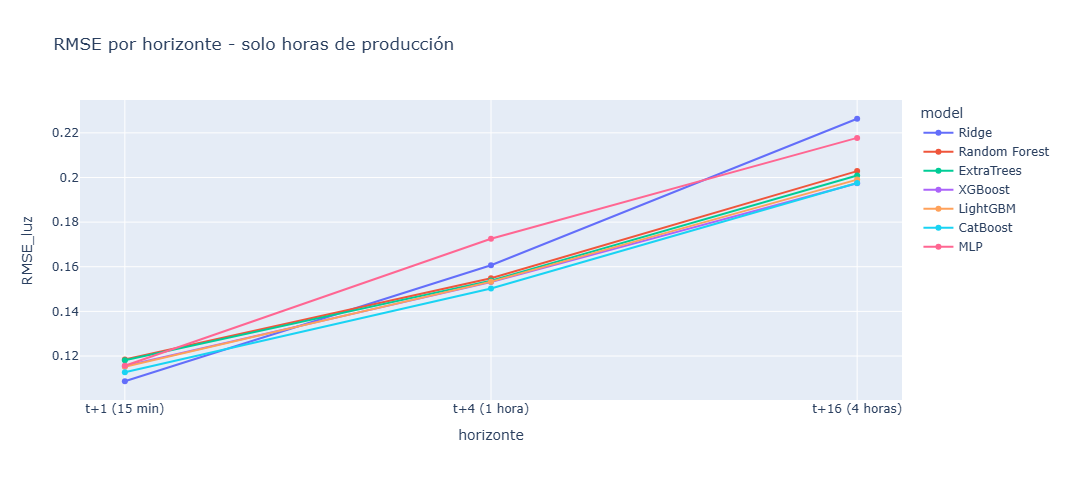

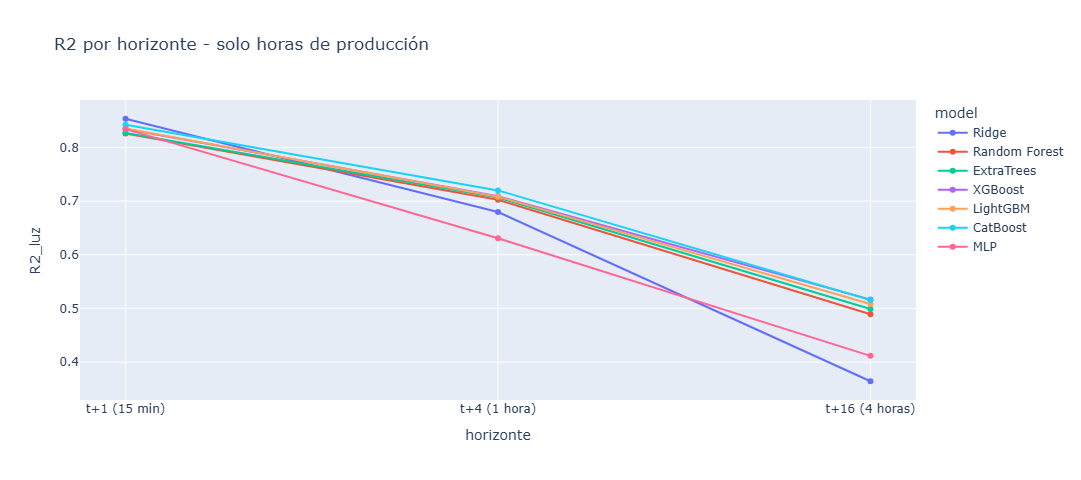

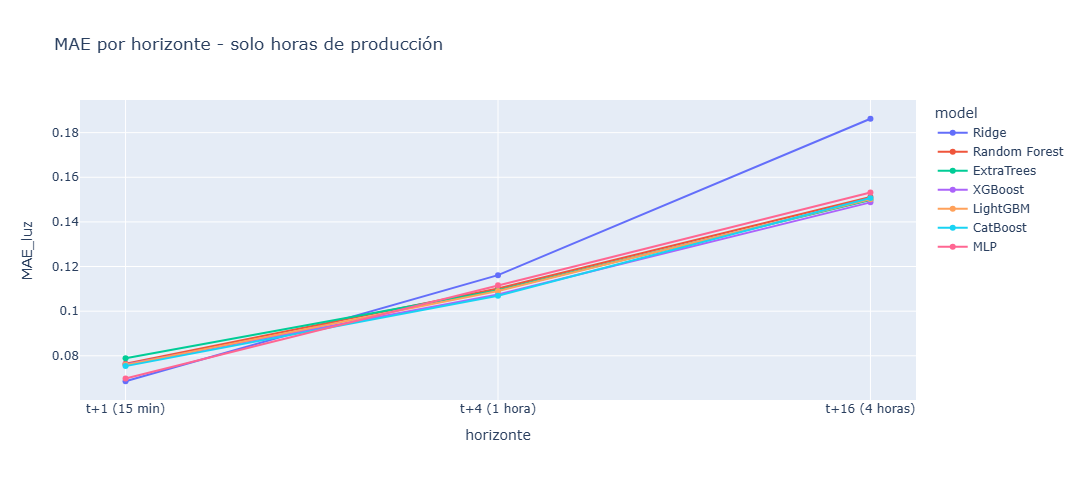

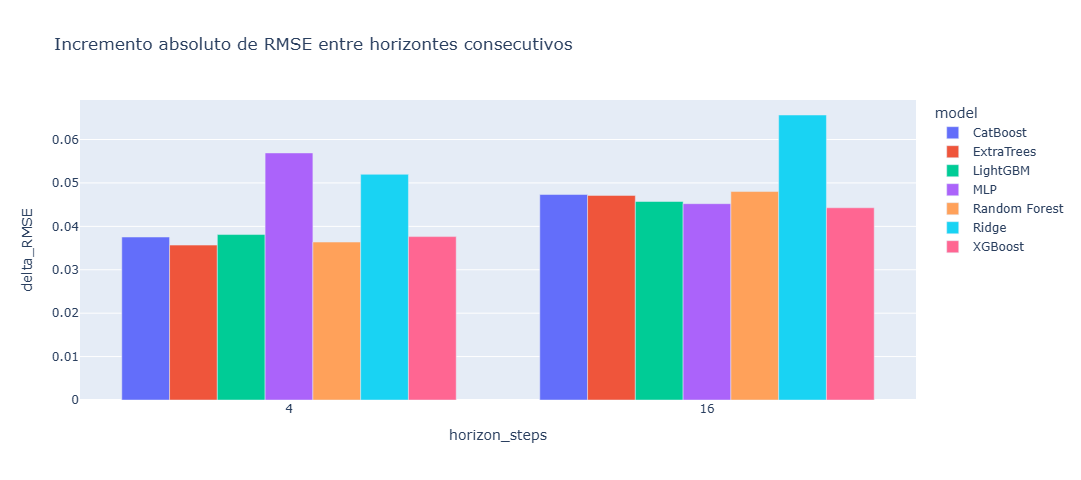

In [6]:
ORDER = ["t+1 (15 min)", "t+4 (1 hora)", "t+16 (4 horas)"]
df_plot = df_horizons.sort_values("horizon_steps")

for metric, title in [
    ("RMSE_luz", "RMSE por horizonte - solo horas de producción"),
    ("R2_luz",   "R2 por horizonte - solo horas de producción"),
    ("MAE_luz",  "MAE por horizonte - solo horas de producción"),
]:
    fig = px.line(
        df_plot, x="horizonte", y=metric, color="model",
        markers=True, title=title,
        category_orders={"horizonte": ORDER},
    )
    fig.update_layout(width=1000, height=480, yaxis_title=metric)
    fig.show()

# Incremento de RMSE entre horizontes consecutivos
df_delta = df_horizons.sort_values(["model", "horizon_steps"]).copy()
df_delta["delta_RMSE"] = df_delta.groupby("model")["RMSE_luz"].diff()
fig = px.bar(
    df_delta.dropna(),
    x="horizon_steps", y="delta_RMSE", color="model", barmode="group",
    title="Incremento absoluto de RMSE entre horizontes consecutivos",
)
fig.update_layout(width=1000, height=480)
fig.show()


### 7. Degradación relativa respecto a t+1
Cuánto empeora cada modelo (en %) al pasar de t+1 a horizontes más lejanos.
Un valor elevado indica que el modelo depende en exceso de la información
inmediata del pasado y pierde capacidad predictiva rápido.


Degradación relativa del RMSE respecto a t+1 (%):
(positivo = el modelo empeora respecto al horizonte base)



horizonte,t+1 (15 min),t+16 (4 horas),t+4 (1 hora)
model,,,
CatBoost,0.0,75.3,33.3
ExtraTrees,0.0,70.1,30.2
LightGBM,0.0,72.8,33.1
MLP,0.0,88.3,49.2
Random Forest,0.0,71.2,30.7
Ridge,0.0,108.2,47.8
XGBoost,0.0,70.9,32.6


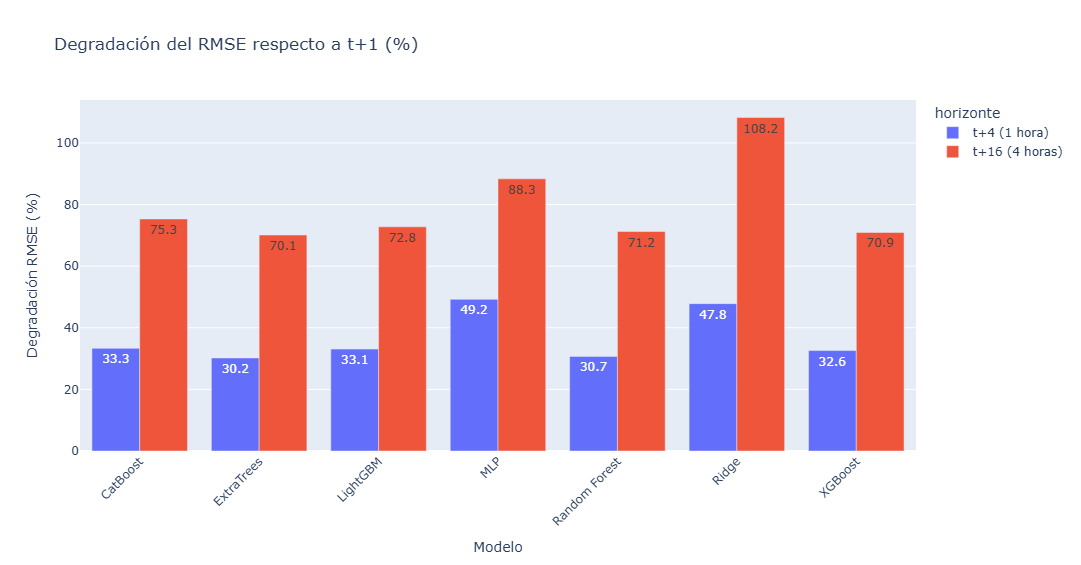


Ranking de robustez temporal:
(menor degradación media = modelo más robusto)



,degradacion_media_pct
model,
ExtraTrees,50.2
Random Forest,51.0
XGBoost,51.8
LightGBM,52.9
CatBoost,54.3
MLP,68.8
Ridge,78.0


In [8]:
base_h1 = (
    df_horizons[df_horizons["horizon_steps"] == 1]
    [["model", "RMSE_luz", "MAE_luz"]]
    .rename(columns={
        "RMSE_luz": "RMSE_h1",
        "MAE_luz": "MAE_h1"
    })
)

df_deg = df_horizons.merge(base_h1, on="model", how="left")

df_deg["RMSE_degradacion_pct"] = (
    (df_deg["RMSE_luz"] - df_deg["RMSE_h1"])
    / df_deg["RMSE_h1"] * 100
)

df_deg["MAE_degradacion_pct"] = (
    (df_deg["MAE_luz"] - df_deg["MAE_h1"])
    / df_deg["MAE_h1"] * 100
)

pivot = df_deg.pivot_table(
    index="model",
    columns="horizonte",
    values="RMSE_degradacion_pct"
).round(1)

print("Degradación relativa del RMSE respecto a t+1 (%):")
print("(positivo = el modelo empeora respecto al horizonte base)\n")
display(pivot)

df_deg_plot = (
    df_deg[df_deg["horizon_steps"] > 1]
    .sort_values(["horizon_steps", "model"])
)

fig = px.bar(
    df_deg_plot,
    x="model",
    y="RMSE_degradacion_pct",
    color="horizonte",
    barmode="group",
    text_auto=".1f",
    title="Degradación del RMSE respecto a t+1 (%)",
    category_orders={
        "horizonte": ["t+4 (1 hora)", "t+16 (4 horas)"]
    },
)

fig.update_layout(
    width=1200,
    height=550,
    yaxis_title="Degradación RMSE (%)",
    xaxis_title="Modelo",
    xaxis_tickangle=-45,
)

fig.show()

robustez = (
    df_deg[df_deg["horizon_steps"] > 1]
    .groupby("model")["RMSE_degradacion_pct"]
    .mean()
    .sort_values()
)

print("\nRanking de robustez temporal:")
print("(menor degradación media = modelo más robusto)\n")

display(
    robustez.to_frame("degradacion_media_pct").round(1)
)

### 8. Importancia de features por horizonte (LightGBM)
Se analiza como cambia el peso relativo de `power_pu_lag_1` frente a
*features* físicas (radiación, temperatura) al aumentar el horizonte.
La hipótesis es que `lag_1` pierde relevancia al alejarse del momento
de predicción, cediendo protagonismo a variables climáticas.


2026-05-27 12:52:37 - INFO - Split: train=138986 | val=11330 | test=8639
2026-05-27 12:52:38 - INFO - Split: train=138986 | val=11330 | test=8639
2026-05-27 12:52:40 - INFO - Split: train=138986 | val=11330 | test=8639


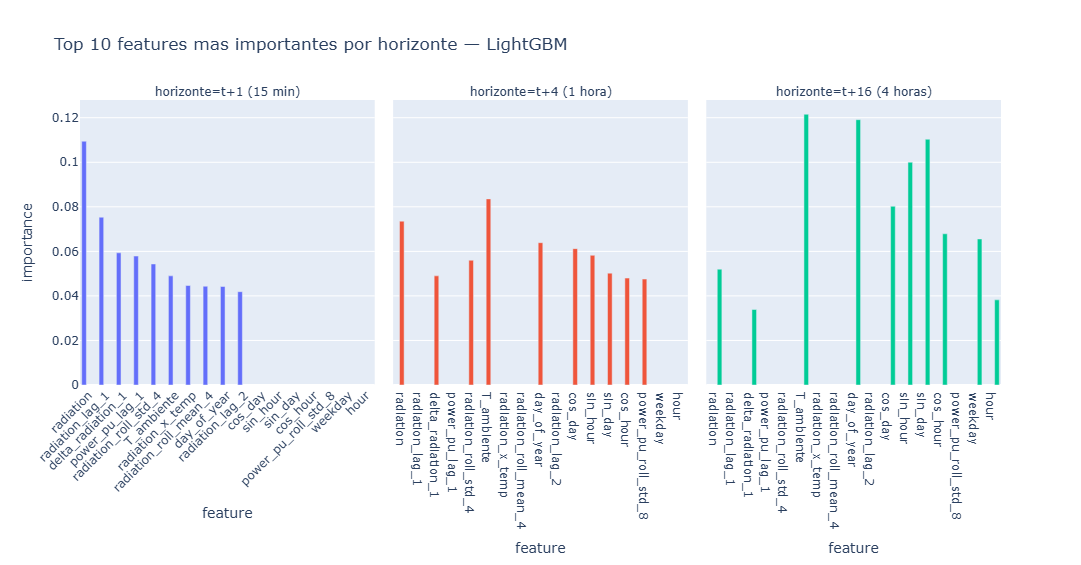

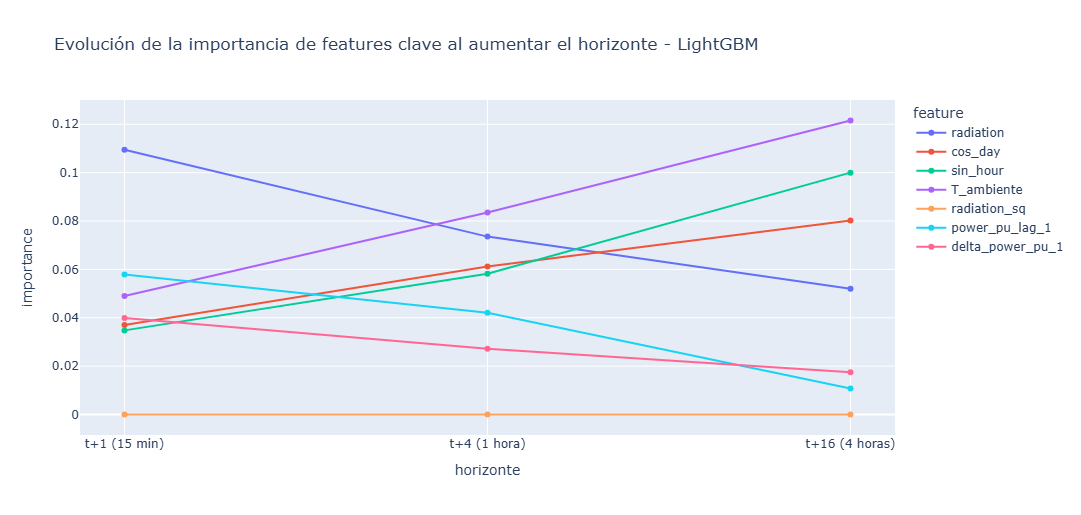

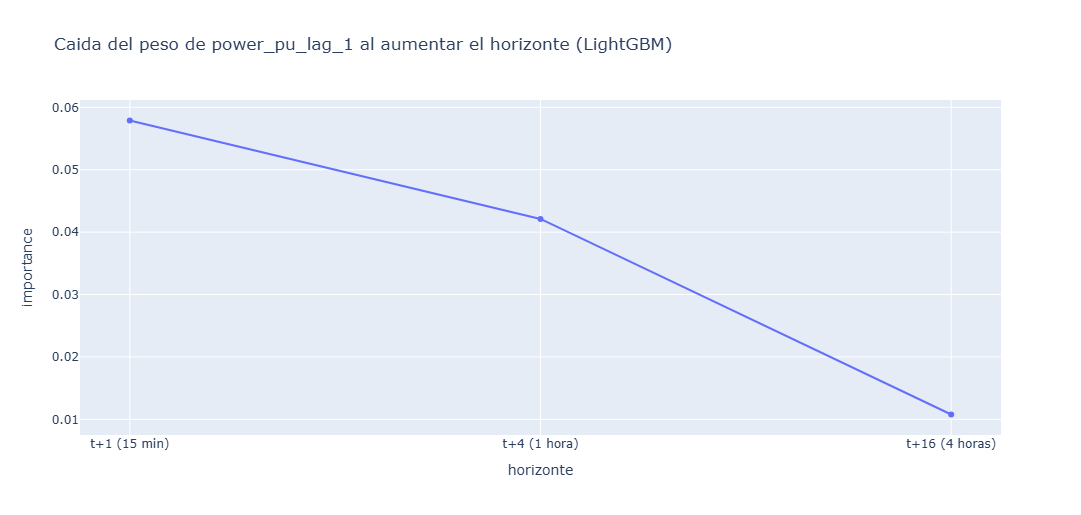

In [9]:
from lightgbm import LGBMRegressor

importance_results = []

for h, label in HORIZONS.items():
    target_col = f"power_pu_h{h}"
    df_h = df_feat.copy()
    df_h["power_pu"] = df_h[target_col]

    train_df, _, _ = split_train_val_test(
        df_h,
        train_plants=["Afrisol", "E03"],
        test_plant="LECA1",
        train_end="2023-12-31",
        val_start="2024-01-01",
        val_end="2024-02-29",
        test_start="2024-03-01",
        test_end="2024-05-30",
    )

    lgbm = LGBMRegressor(
        n_estimators=300, learning_rate=0.05, random_state=42, verbosity=-1
    )
    lgbm.fit(train_df[feature_cols], train_df["power_pu"])

    imp = pd.Series(lgbm.feature_importances_, index=feature_cols)
    imp = imp / imp.sum()

    for feat, val in imp.items():
        importance_results.append({
            "horizonte": label, "horizon_steps": h,
            "feature": feat, "importance": val,
        })

df_imp = pd.DataFrame(importance_results)

# Top 10 por horizonte
top_features = (
    df_imp.groupby(["horizonte", "feature"])["importance"].mean().reset_index()
    .sort_values(["horizonte", "importance"], ascending=[True, False])
    .groupby("horizonte").head(10)
)
fig = px.bar(
    top_features.sort_values(["horizonte", "importance"], ascending=[True, False]),
    x="feature", y="importance", color="horizonte",
    facet_col="horizonte", barmode="group",
    title="Top 10 features mas importantes por horizonte — LightGBM",
    category_orders={"horizonte": ["t+1 (15 min)", "t+4 (1 hora)", "t+16 (4 horas)"]},
)
fig.update_layout(width=1400, height=550, xaxis_tickangle=-45, showlegend=False)
fig.show()

# Evolucion de features clave
key_features = [
    "power_pu_lag_1", "delta_power_pu_1", "radiation",
    "radiation_sq", "cos_day", "sin_hour", "T_ambiente",
]
fig2 = px.line(
    df_imp[df_imp["feature"].isin(key_features)].sort_values("horizon_steps"),
    x="horizonte", y="importance", color="feature", markers=True,
    title="Evolución de la importancia de features clave al aumentar el horizonte - LightGBM",
    category_orders={"horizonte": ["t+1 (15 min)", "t+4 (1 hora)", "t+16 (4 horas)"]},
)
fig2.update_layout(width=1100, height=500)
fig2.show()

# Caida del peso de lag_1
fig3 = px.line(
    df_imp[df_imp["feature"] == "power_pu_lag_1"].sort_values("horizon_steps"),
    x="horizonte", y="importance", markers=True,
    title="Caida del peso de power_pu_lag_1 al aumentar el horizonte (LightGBM)",
    category_orders={"horizonte": ["t+1 (15 min)", "t+4 (1 hora)", "t+16 (4 horas)"]},
)
fig3.update_layout(width=1100, height=500)
fig3.show()


### 9. Guardado de resultados


In [10]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
df_horizons.to_csv(RESULTS_DIR / "exp5_horizontes_metricas.csv",    index=False)
df_deg.to_csv(     RESULTS_DIR / "exp5_horizontes_degradacion.csv", index=False)
df_imp.to_csv(     RESULTS_DIR / "exp5_horizontes_importancia.csv", index=False)

print("Resultados guardados en data/results/:")
print("  exp5_horizontes_metricas.csv    — MAE, RMSE, R2 por modelo y horizonte")
print("  exp5_horizontes_degradacion.csv — degradacion relativa respecto a t+1")
print("  exp5_horizontes_importancia.csv — importancia de features (LightGBM)")


Resultados guardados en data/results/:
  exp5_horizontes_metricas.csv    — MAE, RMSE, R2 por modelo y horizonte
  exp5_horizontes_degradacion.csv — degradacion relativa respecto a t+1
  exp5_horizontes_importancia.csv — importancia de features (LightGBM)


## Conclusiones del Experimento 5

**Degradación no lineal:** el error no crece de forma proporcional al horizonte;
el salto más brusco se produce entre t+1 y t+4 en todos los modelos.

**Ridge es el modelo más frágil:** al depender casi exclusivamente de `lag_1`
y `delta_power_pu_1`, su capacidad predictiva colapsa en horizontes superiores
a 1 hora, confirmando la hipótesis inicial.

**LightGBM y XGBoost son los más robustos:** capturan relaciones físicas
entre radiación y producción que mantienen valor predictivo incluso a 4 horas.

**Cambio de features dominantes:** en t+1, `lag_1` es la *feature* más importante.
En t+16, la radiación y las variables temporales toman el protagonismo, lo que
confirma que el modelo compensa la pérdida de información reciente con el
contexto físico.

| Ranking robustez | Modelo | Degradación media (%) |
|---|---|---:|
| 1 | ExtraTrees | 50.2 |
| 2 | Random Forest | 51.0 |
| 3 | XGBoost | 51.8 |
| 4 | LightGBM | 52.9 |
| 5 | CatBoost | 54.3 |
| 6 | MLP | 68.8 |
| 7 | Ridge | 78.0 |

**Archivos de salida:**
- `data/results/exp5_horizontes_metricas.csv`
- `data/results/exp5_horizontes_degradacion.csv`
- `data/results/exp5_horizontes_importancia.csv`
